# 🗺️ Drainage Analysis — Professional Map Suite
### Copernicus DEM · ESA WorldCover · CN Grid · HSG Grid · Manning's n
---
**Layers (UTM Projection):**
| # | Layer | Type | File |
|---|-------|------|------|
| 1 | Copernicus DEM 30m | Continuous | `Extract_outp1.tif` |
| 2 | ESA WorldCover LULC | Categorical | `ESA_WorldCover_UTM.tif` |
| 3 | Curve Number Grid | Continuous | `CN_Grid_UTM.tif` |
| 4 | Hydrological Soil Group | Categorical | `HSG_Grid_UTM.tif` |
| 5 | Manning's Roughness Coefficient | Continuous | `Mannings_n_Grid_UTM.tif` |

**Each map includes:** Hillshade background · DMS grid · North arrow · Scale bar · Stretched legend · 300 DPI export


## ⚙️ Step 1 — Install Required Libraries

In [1]:
%%capture
!apt-get update -qq > /dev/null
!apt-get install -y fonts-times-romans > /dev/null
!pip install rasterio cartopy matplotlib_scalebar
!rm -rf ~/.cache/matplotlib # Clear matplotlib font cache
import matplotlib.font_manager
print("✅ Libraries and fonts installed!")

## 📦 Step 2 — Import Libraries

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import rasterio
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from google.colab import files
import zipfile
import warnings
warnings.filterwarnings('ignore')

# ── Global style settings ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Serif', # Changed font family
    'axes.linewidth'   : 1.4,
    'figure.facecolor' : 'white',
    'savefig.dpi'      : 300,
})
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 3 — Upload Raster Files

In [3]:
print("Upload your 5 GeoTIFF rasters:")
print("  • Extract_outp1.tif       ← DEM (Copernicus 30m)")
print("  • ESA_WorldCover_UTM.tif  ← LULC")
print("  • CN_Grid_UTM.tif         ← Curve Number")
print("  • HSG_Grid_UTM.tif        ← Hydrological Soil Group")
print("  • Mannings_n_Grid_UTM.tif ← Manning's n")
uploaded = files.upload()
print("\n✅ Uploaded:", list(uploaded.keys()))


Upload your 5 GeoTIFF rasters:
  • Extract_outp1.tif       ← DEM (Copernicus 30m)
  • ESA_WorldCover_UTM.tif  ← LULC
  • CN_Grid_UTM.tif         ← Curve Number
  • HSG_Grid_UTM.tif        ← Hydrological Soil Group
  • Mannings_n_Grid_UTM.tif ← Manning's n


Saving CN_Grid_UTM.tif to CN_Grid_UTM.tif
Saving ESA_WorldCover_UTM.tif to ESA_WorldCover_UTM.tif
Saving Extract_outp1.tif to Extract_outp1.tif
Saving HSG_Grid_UTM.tif to HSG_Grid_UTM.tif
Saving Mannings_n_Grid_UTM.tif to Mannings_n_Grid_UTM.tif

✅ Uploaded: ['CN_Grid_UTM.tif', 'ESA_WorldCover_UTM.tif', 'Extract_outp1.tif', 'HSG_Grid_UTM.tif', 'Mannings_n_Grid_UTM.tif']


## 📝 Step 4 — Configure File Paths
> ⚠️ Edit the filenames below to match your uploaded files exactly.

In [4]:
# ─── ⚠️  EDIT THESE FILENAMES TO MATCH YOUR UPLOADS ──────────────────────── #
DEM_PATH  = 'Extract_outp1.tif'
LULC_PATH = 'ESA_WorldCover_UTM.tif'
CN_PATH   = 'CN_Grid_UTM.tif'
HSG_PATH  = 'HSG_Grid_UTM.tif'
MANN_PATH = 'Mannings_n_Grid_UTM.tif'

# ─── Study area title (shown on every map) ────────────────────────────────── #
WATERSHED_NAME = 'GADHI RIVER BASIN'   # ← Change to your watershed/basin name

# ─── Output folder ───────────────────────────────────────────────────────── #
OUTPUT_DIR = '/content/DA_Maps'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Output directory ready: {OUTPUT_DIR}")

# ─── Global buffer for map extent ────────────────────────────────────────── #
BUFFER_PERCENTAGE = 0.05

✅ Output directory ready: /content/DA_Maps


## 🛠️ Step 5 — Helper Functions

In [108]:
import numpy as np, os, zipfile
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
from matplotlib.colors import LinearSegmentedColormap
import rasterio
from rasterio.transform import Affine
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from matplotlib_scalebar.scalebar import ScaleBar

BUFFER_PCT = 0.10
FONT_SERIF = 'DejaVu Serif'
FONT_SIZE_LBL = 10.0
TITLE_SIZE = 16
FIG_SIZE = (16, 13)

ESA_CLASSES = {10: ('Tree Cover', '#006400'), 20: ('Shrubland', '#FFBB22'), 30: ('Grassland', '#FFFF4C'), 40: ('Cropland', '#F096FF'), 50: ('Built-up', '#FA0000'), 60: ('Bare / Sparse Vegetation', '#B4B4B4'), 70: ('Snow and Ice', '#F0F0F0'), 80: ('Permanent Water Bodies', '#0064C8'), 90: ('Herbaceous Wetland', '#0096A0'), 95: ('Mangroves', '#00CF75'), 100: ('Moss and Lichen', '#FAE6A0')}
HSG_CLASSES = {1: ('Group A — Low Runoff', '#2166AC'), 2: ('Group B — Moderate-Low', '#92C5DE'), 3: ('Group C — Moderate-High', '#F4A582'), 4: ('Group D — High Runoff', '#D6604D')}

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        nd = src.nodata
        if nd is not None: data[data == nd] = np.nan
        data[data <= -9999] = np.nan
        return data, src.transform, src.crs, src.bounds, src.crs.to_epsg()

def get_buffered_extent(bounds, pct=BUFFER_PCT):
    dx = (bounds.right - bounds.left) * pct
    dy = (bounds.top - bounds.bottom) * pct
    return [bounds.left - dx, bounds.right + dx, bounds.bottom - dy, bounds.top + dy]

def get_cartopy_crs(epsg):
    try: return ccrs.epsg(epsg)
    except: return ccrs.PlateCarree()

def resample_to_match(src_data, src_tf, src_crs, dst_shape, dst_tf, dst_crs):
    from rasterio.warp import reproject, Resampling
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(source=src_data.astype(np.float32), destination=dst, src_transform=src_tf, src_crs=src_crs, dst_transform=dst_tf, dst_crs=dst_crs, resampling=Resampling.bilinear)
    return dst.astype(float)

def compute_hillshade(elevation, azimuth=315, altitude=45, z_factor=1.0):
    from matplotlib.colors import LightSource
    ls = LightSource(azdeg=azimuth, altdeg=altitude)
    return ls.hillshade(elevation, vert_exag=z_factor)

def add_decimal_grid(ax):
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.7, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = gl.bottom_labels = gl.left_labels = gl.right_labels = True
    gl.xpadding = gl.ypadding = 15
    gl.xformatter = LongitudeFormatter(decimal_point='.', number_format='.1f', degree_symbol='°')
    gl.yformatter = LatitudeFormatter(decimal_point='.', number_format='.1f', degree_symbol='°')
    gl.xlabel_style = gl.ylabel_style = {'size': FONT_SIZE_LBL, 'family': FONT_SERIF}
    return gl

def add_north_arrow(ax, x=0.95, y=0.95):
    # Using a professional scatter marker + text for guaranteed visibility
    ax.text(x, y, 'N', transform=ax.transAxes, ha='center', va='bottom', fontsize=22, fontweight='bold', family=FONT_SERIF, color='black', path_effects=[pe.withStroke(linewidth=4, foreground='white')])
    ax.scatter(x, y-0.04, marker='^', transform=ax.transAxes, s=400, color='black', edgecolor='white', linewidth=1.5, zorder=10)

def add_scalebar(ax, map_crs):
    ax.add_artist(ScaleBar(1.0, location='lower left', box_alpha=0.6, border_pad=1.5, font_properties={'family': FONT_SERIF, 'size': 10}))

def add_colorbar(fig, ax, im, label):
    cb = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.03, pad=0.10, shrink=0.7)
    cb.set_label(label, fontsize=11, fontweight='bold', fontfamily=FONT_SERIF)
    return cb

def finish_map(ax, title, watershed_name, fig, fname):
    plt.title(f"{title}\n{watershed_name}", fontsize=TITLE_SIZE, fontweight='bold', pad=40, family=FONT_SERIF)
    plt.savefig(fname, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

## 🏔️ Step 6 — Load DEM & Compute Hillshade
*The hillshade is shared across all 5 maps as the background layer.*

In [6]:
print("Loading DEM ...")
dem, dem_tf, dem_crs, dem_bounds, dem_epsg = read_raster(DEM_PATH)
hillshade = compute_hillshade(dem, azimuth=315, altitude=60, z_factor=1.0)
map_crs   = get_cartopy_crs(dem_epsg)
extent    = [dem_bounds.left, dem_bounds.right,
             dem_bounds.bottom, dem_bounds.top]

print(f"  Shape       : {dem.shape}")
print(f"  Elev range  : {np.nanmin(dem):.1f} – {np.nanmax(dem):.1f} m")
print(f"  EPSG        : {dem_epsg}")
print(f"  Bounds      : L={dem_bounds.left:.0f}  R={dem_bounds.right:.0f}")
print(f"                B={dem_bounds.bottom:.0f} T={dem_bounds.top:.0f}")
print("✅ Hillshade ready!")

Loading DEM ...
  Shape       : (752, 851)
  Elev range  : -0.2 – 809.8 m
  EPSG        : 32643
  Bounds      : L=293922  R=319922
                B=2090019 T=2113112
✅ Hillshade ready!


## 🗺️ Map 1 — Copernicus DEM 30m

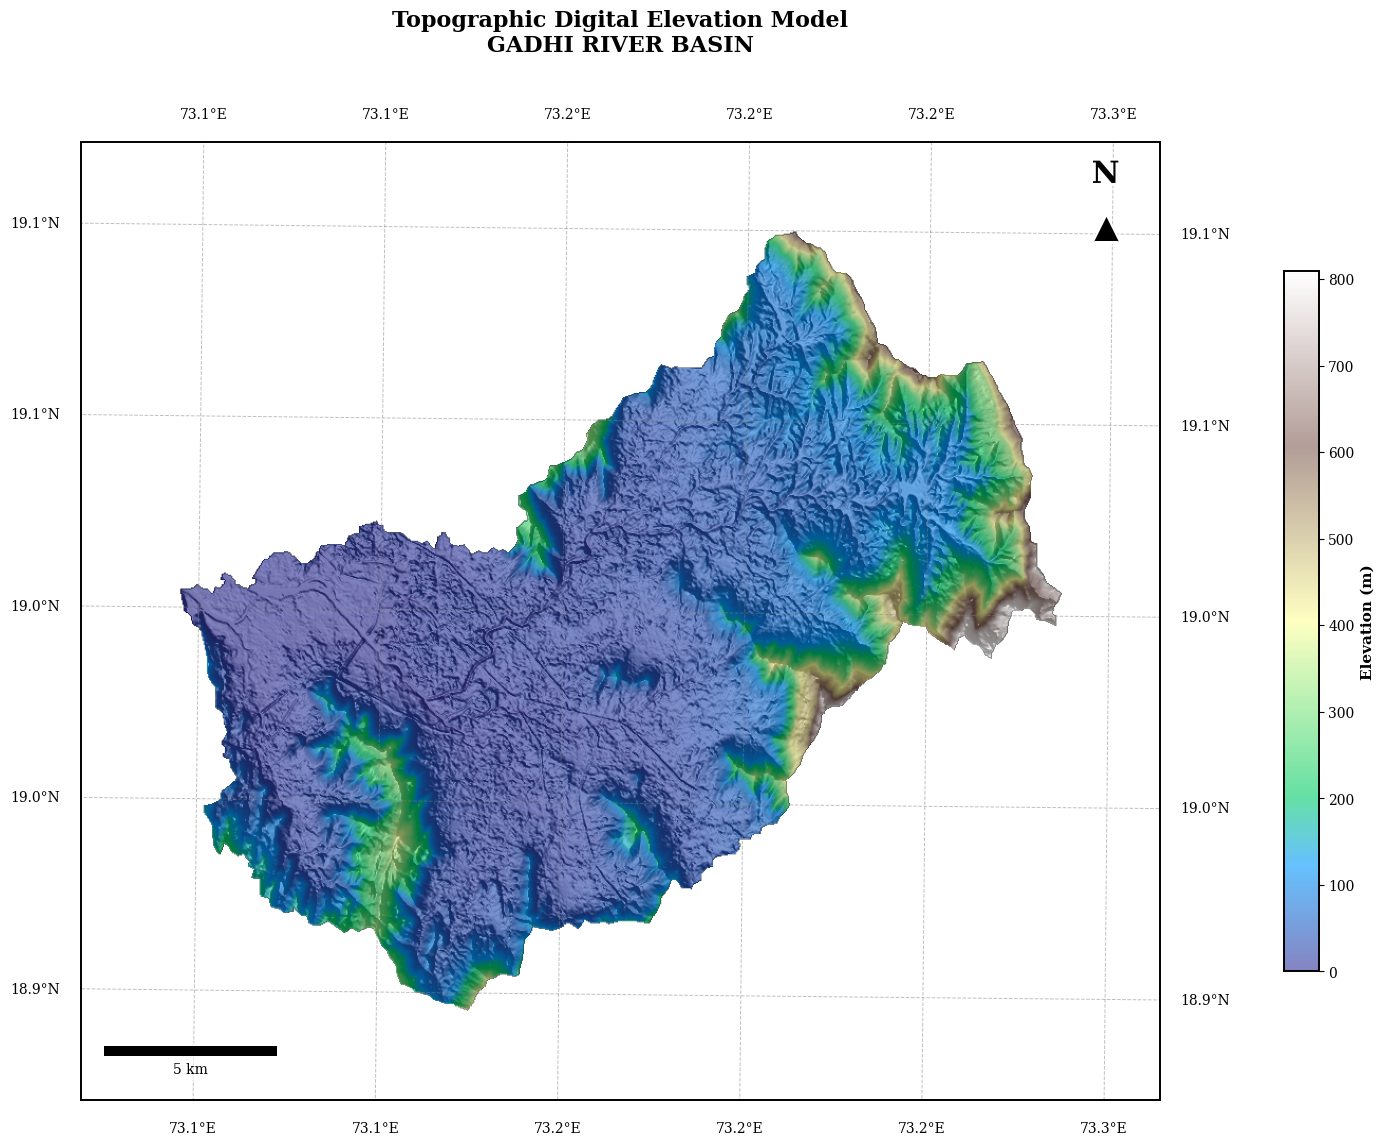

In [109]:
fig = plt.figure(figsize=FIG_SIZE)
ax = fig.add_subplot(1, 1, 1, projection=map_crs)
ax.set_extent(get_buffered_extent(dem_bounds), crs=map_crs)
ax.imshow(np.ma.masked_invalid(hillshade), extent=extent, transform=map_crs, cmap='gray', alpha=1.0, zorder=1)
im = ax.imshow(np.ma.masked_invalid(dem), extent=extent, transform=map_crs, cmap='terrain', alpha=0.6, zorder=2)
add_decimal_grid(ax)
add_north_arrow(ax)
add_scalebar(ax, map_crs)
add_colorbar(fig, ax, im, 'Elevation (m)')
finish_map(ax, 'Topographic Digital Elevation Model', WATERSHED_NAME, fig, f'{OUTPUT_DIR}/01_DEM_Copernicus.png')

## 🗺️ Map 2 — ESA WorldCover LULC

Rendering Map 2 — LULC …


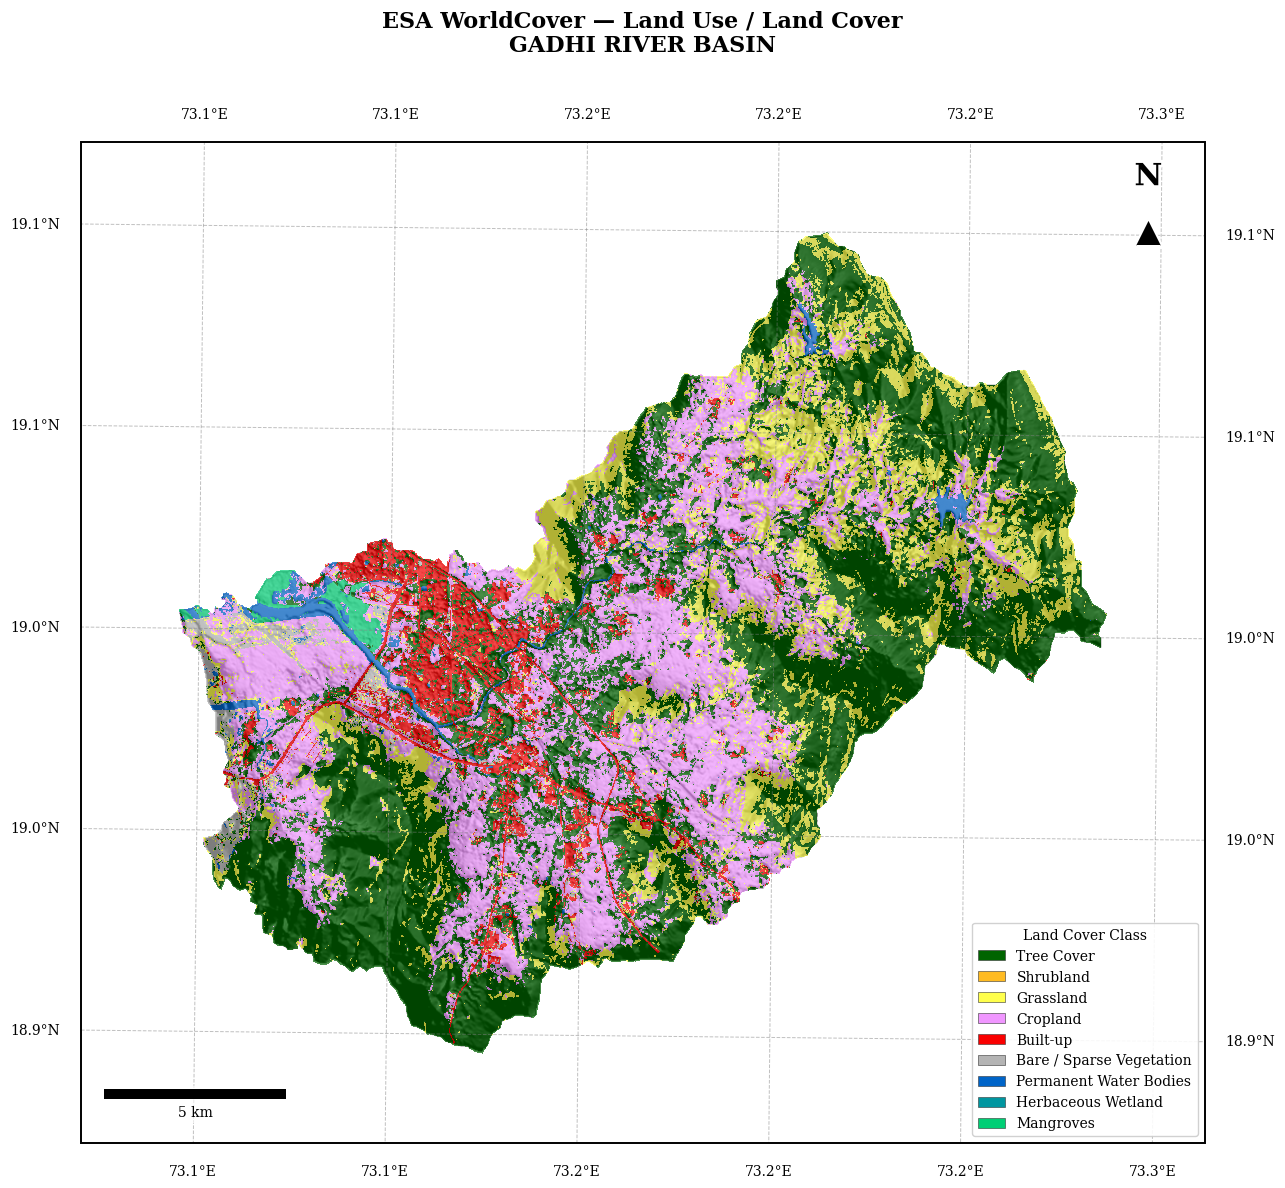

In [111]:
print("Rendering Map 2 — LULC …")
lulc, lulc_tf, lulc_crs, lulc_bounds, lulc_epsg = read_raster(LULC_PATH)
lulc_ext = [lulc_bounds.left, lulc_bounds.right, lulc_bounds.bottom, lulc_bounds.top]
buf_lulc = get_buffered_extent(lulc_bounds)
uniq_vals = np.unique(lulc[~np.isnan(lulc)]).astype(int)
present   = {k: v for k, v in ESA_CLASSES.items() if k in uniq_vals}
cls_vals  = sorted(present.keys())
cmap_lulc = mcolors.ListedColormap([present[c][1] for c in cls_vals])
norm_lulc = mcolors.BoundaryNorm([v - 5 for v in cls_vals] + [cls_vals[-1] + 5], cmap_lulc.N)
fig = plt.figure(figsize=FIG_SIZE)
ax  = fig.add_subplot(1, 1, 1, projection=map_crs)
ax.set_extent(buf_lulc, crs=map_crs)
hs_res = resample_to_match(hillshade, dem_tf, dem_crs, lulc.shape, lulc_tf, lulc_crs)
valid = ~np.isnan(lulc) & (lulc > 0)
ax.imshow(np.ma.masked_where(~valid | np.isnan(hs_res), hs_res), extent=lulc_ext, transform=map_crs, cmap='gray', vmin=0, vmax=1, zorder=1)
im = ax.imshow(np.ma.masked_where(~valid, lulc), extent=lulc_ext, transform=map_crs, cmap=cmap_lulc, norm=norm_lulc, alpha=0.7, zorder=2, interpolation='none')
add_decimal_grid(ax)
add_north_arrow(ax)
add_scalebar(ax, map_crs)
patches = [mpatches.Patch(facecolor=present[c][1], edgecolor='#333333', linewidth=0.4, label=present[c][0]) for c in cls_vals]
ax.legend(handles=patches, loc='lower right', fontsize=9, title='Land Cover Class', framealpha=0.9, prop={'family': FONT_SERIF})
finish_map(ax, 'ESA WorldCover — Land Use / Land Cover', WATERSHED_NAME, fig, f'{OUTPUT_DIR}/02_LULC_ESA_WorldCover.png')

## 🗺️ Map 3 — Curve Number (CN) Grid

Rendering Map 3 — Curve Number …


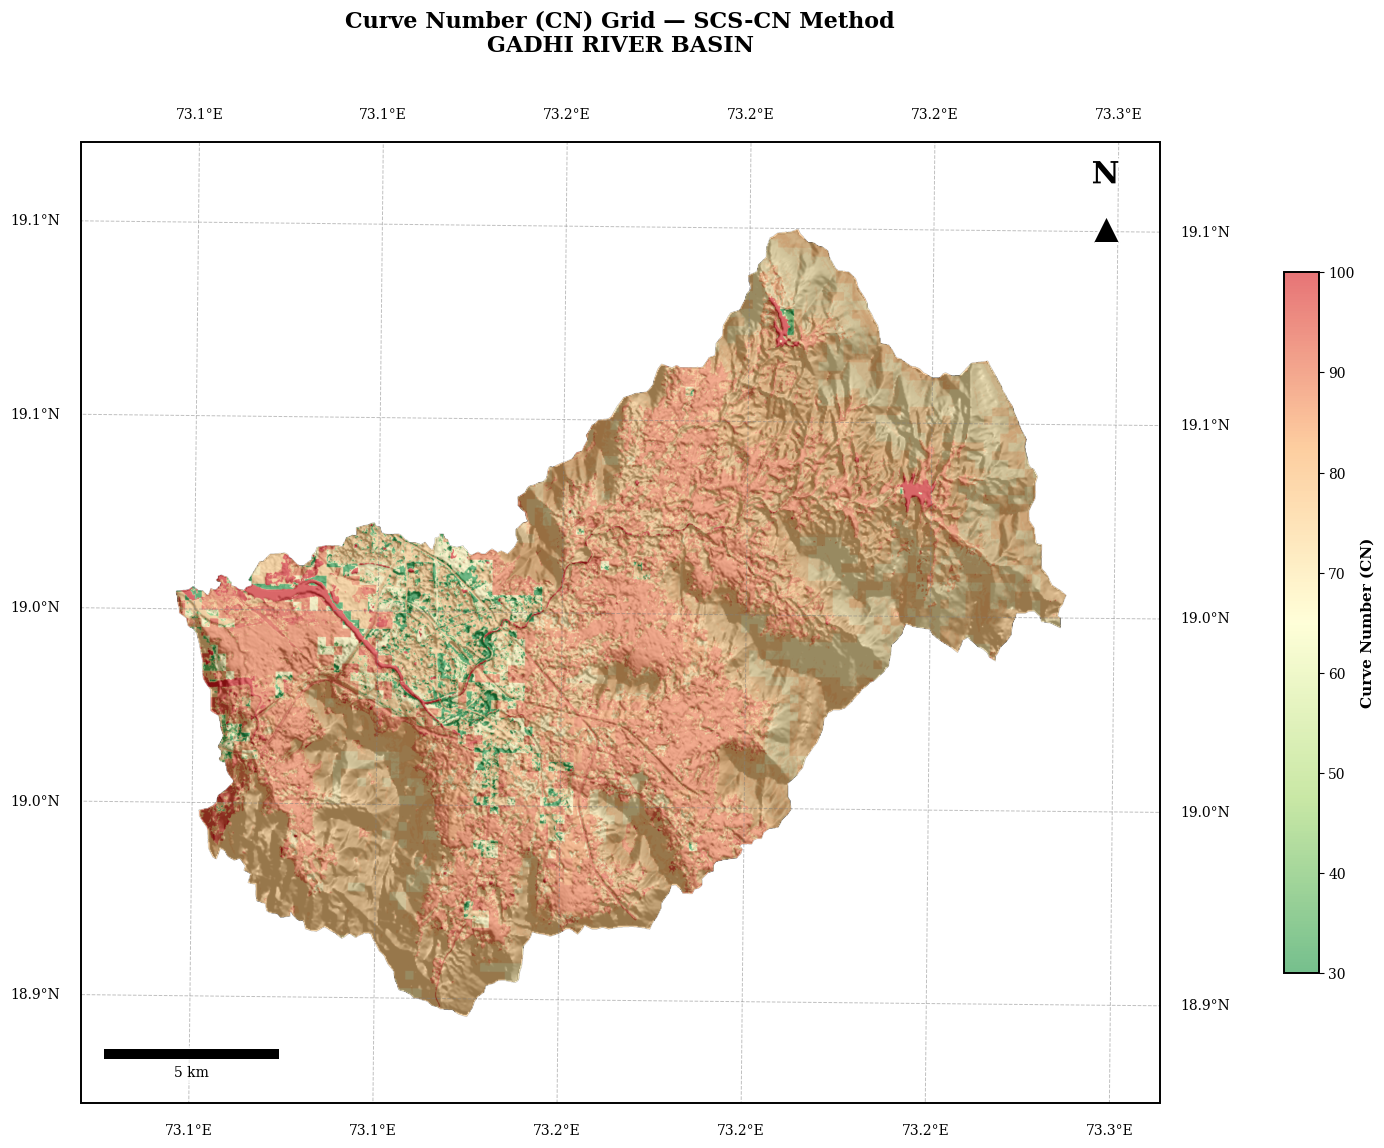

In [112]:
print("Rendering Map 3 — Curve Number …")
cn, cn_tf, cn_crs, cn_bounds, cn_epsg = read_raster(CN_PATH)
cn_ext = [cn_bounds.left, cn_bounds.right, cn_bounds.bottom, cn_bounds.top]
buf_cn = get_buffered_extent(cn_bounds)
cmap_cn = LinearSegmentedColormap.from_list('CN', ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c'], N=256)
fig = plt.figure(figsize=FIG_SIZE)
ax  = fig.add_subplot(1, 1, 1, projection=map_crs)
ax.set_extent(buf_cn, crs=map_crs)
hs_res_cn = resample_to_match(hillshade, dem_tf, dem_crs, cn.shape, cn_tf, cn_crs)
ax.imshow(np.ma.masked_where(np.isnan(cn) | np.isnan(hs_res_cn), hs_res_cn), extent=cn_ext, transform=map_crs, cmap='gray', vmin=0, vmax=1, zorder=1)
im = ax.imshow(np.ma.masked_invalid(cn), extent=cn_ext, transform=map_crs, cmap=cmap_cn, alpha=0.6, zorder=2)
add_decimal_grid(ax)
add_north_arrow(ax)
add_scalebar(ax, map_crs)
add_colorbar(fig, ax, im, 'Curve Number (CN)')
finish_map(ax, 'Curve Number (CN) Grid — SCS-CN Method', WATERSHED_NAME, fig, f'{OUTPUT_DIR}/03_CN_Grid.png')

## 🗺️ Map 4 — Hydrological Soil Group (HSG)

Rendering Map 4 — HSG …


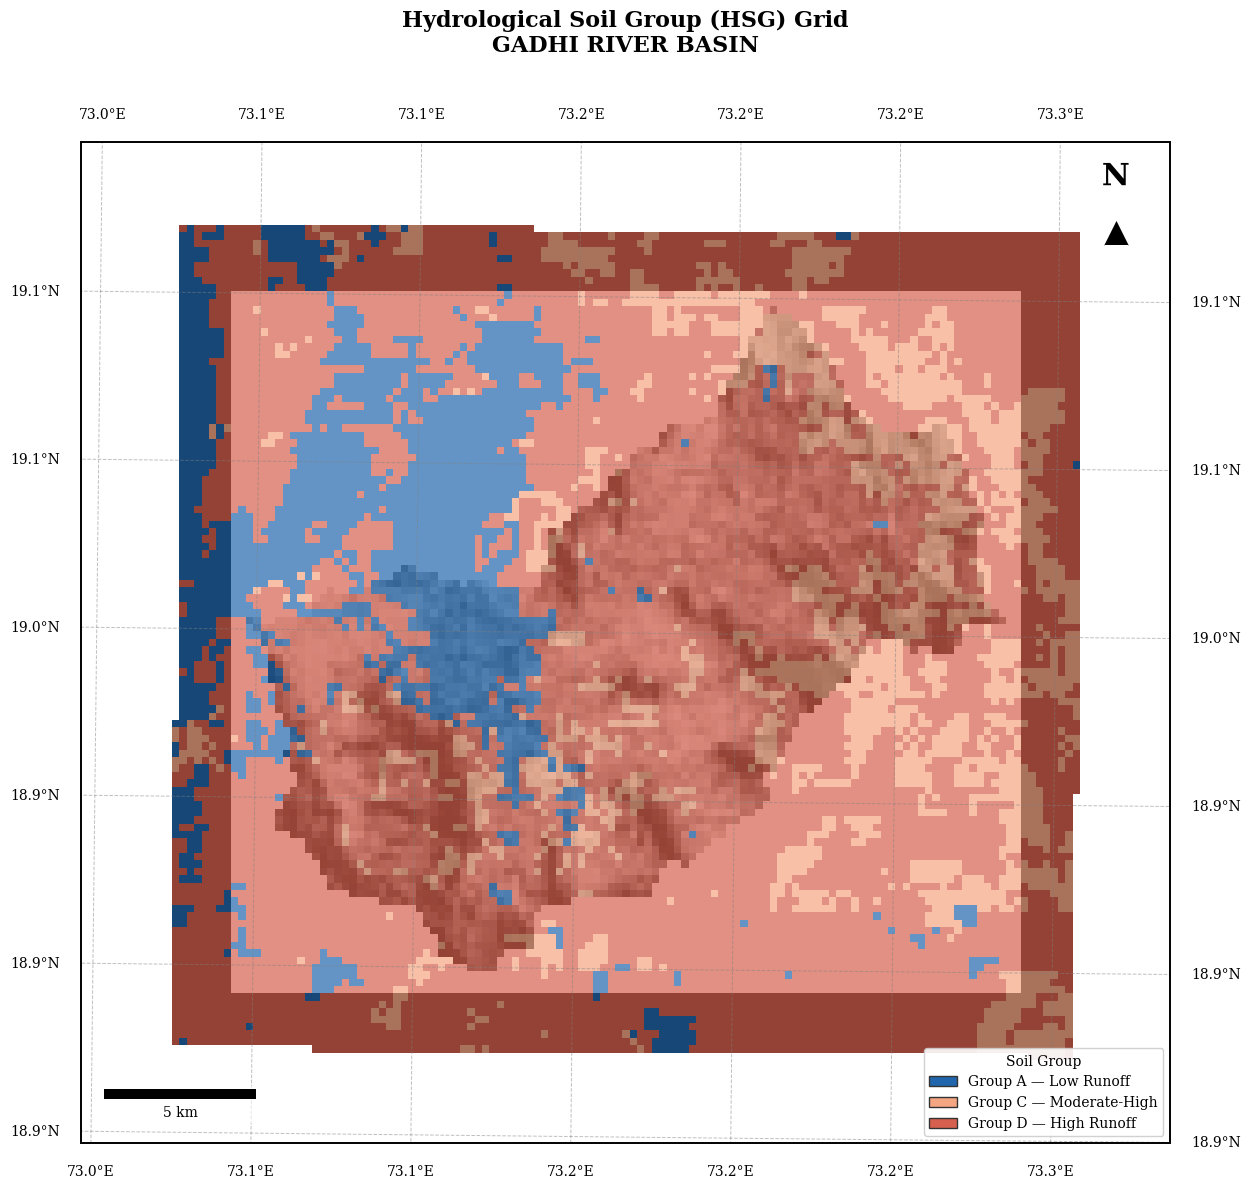

In [113]:
print("Rendering Map 4 — HSG …")
hsg, hsg_tf, hsg_crs, hsg_bounds, hsg_epsg = read_raster(HSG_PATH)
hsg_ext = [hsg_bounds.left, hsg_bounds.right, hsg_bounds.bottom, hsg_bounds.top]
buf_hsg = get_buffered_extent(hsg_bounds)
uniq_hsg = np.unique(hsg[~np.isnan(hsg)]).astype(int)
pres_hsg = {k: v for k, v in HSG_CLASSES.items() if k in uniq_hsg}
hsg_vals = sorted(pres_hsg.keys())
cmap_hsg = mcolors.ListedColormap([pres_hsg[h][1] for h in hsg_vals])
norm_hsg = mcolors.BoundaryNorm([v - 0.5 for v in hsg_vals] + [hsg_vals[-1] + 0.5], cmap_hsg.N)
fig = plt.figure(figsize=FIG_SIZE)
ax  = fig.add_subplot(1, 1, 1, projection=map_crs)
ax.set_extent(buf_hsg, crs=map_crs)
hs_res_hsg = resample_to_match(hillshade, dem_tf, dem_crs, hsg.shape, hsg_tf, hsg_crs)
ax.imshow(np.ma.masked_where(np.isnan(hsg) | np.isnan(hs_res_hsg), hs_res_hsg), extent=hsg_ext, transform=map_crs, cmap='gray', vmin=0, vmax=1, zorder=1)
im = ax.imshow(np.ma.masked_invalid(hsg), extent=hsg_ext, transform=map_crs, cmap=cmap_hsg, norm=norm_hsg, alpha=0.7, zorder=2)
add_decimal_grid(ax)
add_north_arrow(ax)
add_scalebar(ax, map_crs)
patches = [mpatches.Patch(facecolor=pres_hsg[h][1], edgecolor='#333333', label=pres_hsg[h][0]) for h in hsg_vals]
ax.legend(handles=patches, loc='lower right', fontsize=9, title='Soil Group', framealpha=0.9, prop={'family': FONT_SERIF})
finish_map(ax, 'Hydrological Soil Group (HSG) Grid', WATERSHED_NAME, fig, f'{OUTPUT_DIR}/04_HSG_Grid.png')

## 🗺️ Map 5 — Manning's Roughness Coefficient (n)

Rendering Map 5 — Manning's n …


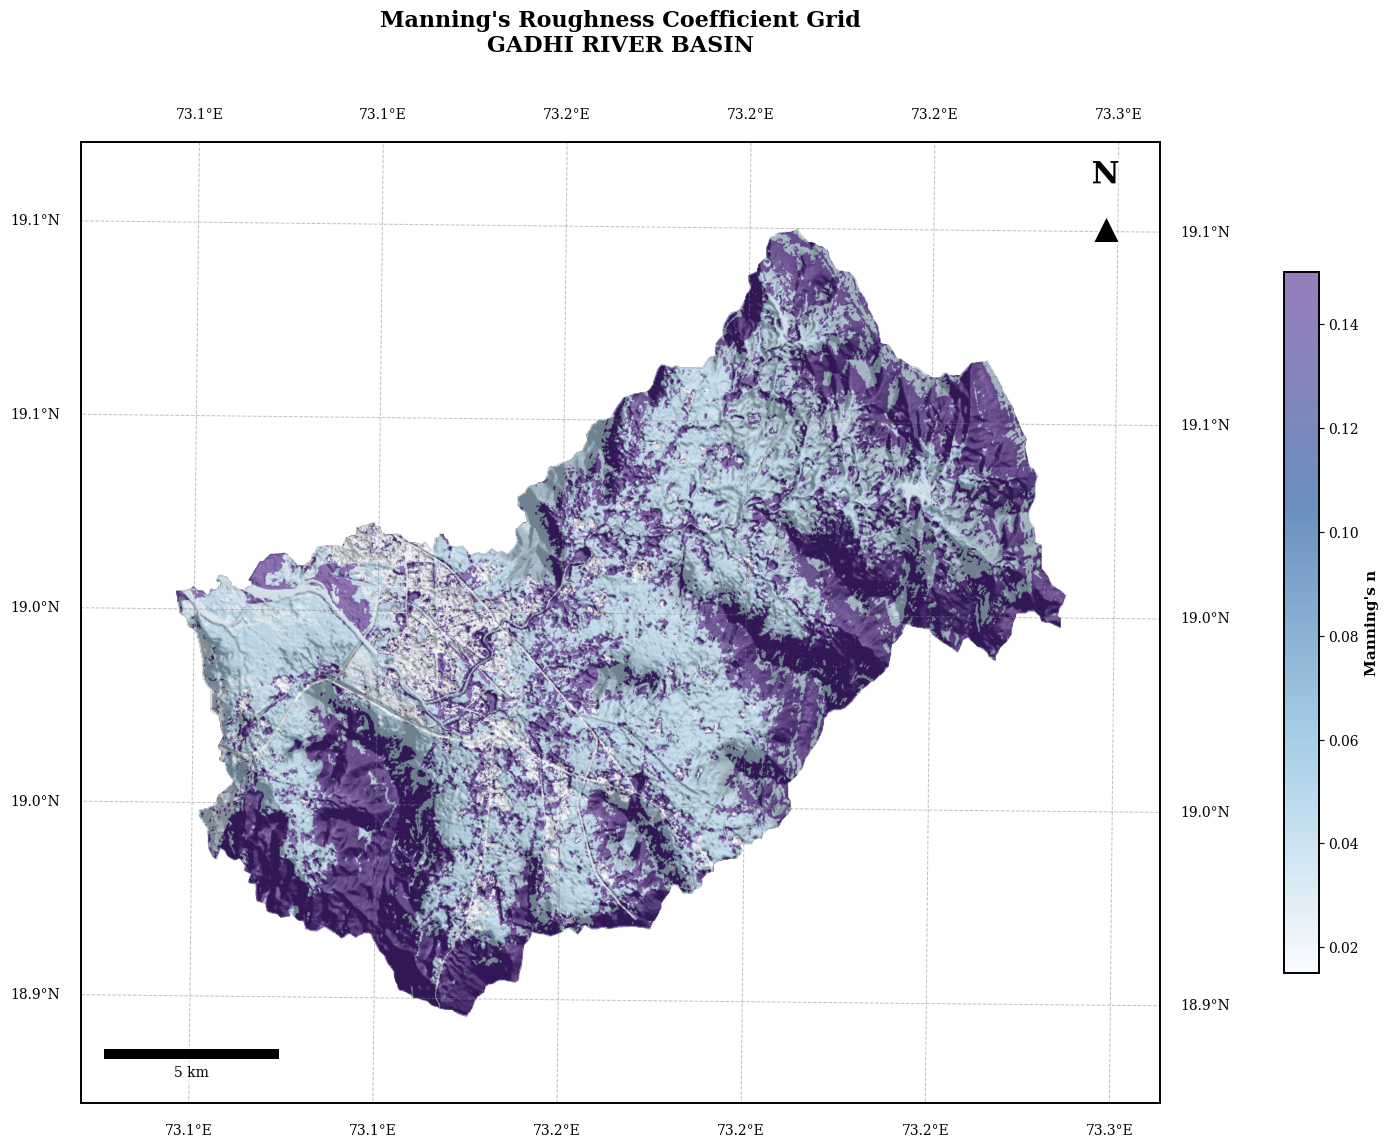

In [114]:
print("Rendering Map 5 — Manning's n …")
mann, mann_tf, mann_crs, mann_bounds, mann_epsg = read_raster(MANN_PATH)
mann_ext = [mann_bounds.left, mann_bounds.right, mann_bounds.bottom, mann_bounds.top]
buf_mann = get_buffered_extent(mann_bounds)
cmap_mann = LinearSegmentedColormap.from_list('Manning', ['#f7fbff', '#6baed6', '#084594', '#54278f'], N=256)
fig = plt.figure(figsize=FIG_SIZE)
ax  = fig.add_subplot(1, 1, 1, projection=map_crs)
ax.set_extent(buf_mann, crs=map_crs)
hs_res_mann = resample_to_match(hillshade, dem_tf, dem_crs, mann.shape, mann_tf, mann_crs)
ax.imshow(np.ma.masked_where(np.isnan(mann) | np.isnan(hs_res_mann), hs_res_mann), extent=mann_ext, transform=map_crs, cmap='gray', vmin=0, vmax=1, zorder=1)
im = ax.imshow(np.ma.masked_invalid(mann), extent=mann_ext, transform=map_crs, cmap=cmap_mann, alpha=0.6, zorder=2)
add_decimal_grid(ax)
add_north_arrow(ax)
add_scalebar(ax, map_crs)
add_colorbar(fig, ax, im, "Manning's n")
finish_map(ax, "Manning's Roughness Coefficient Grid", WATERSHED_NAME, fig, f'{OUTPUT_DIR}/05_Mannings_n.png')

## 📥 Step 7 — Download All Maps

## 🗺️ Map 6 — Reservoir Submergence Area
*Using the provided shapefile overlays on the Copernicus DEM background.*

Rendering Map 6 — Reservoir Submergence & Dam Wall with Basemap …


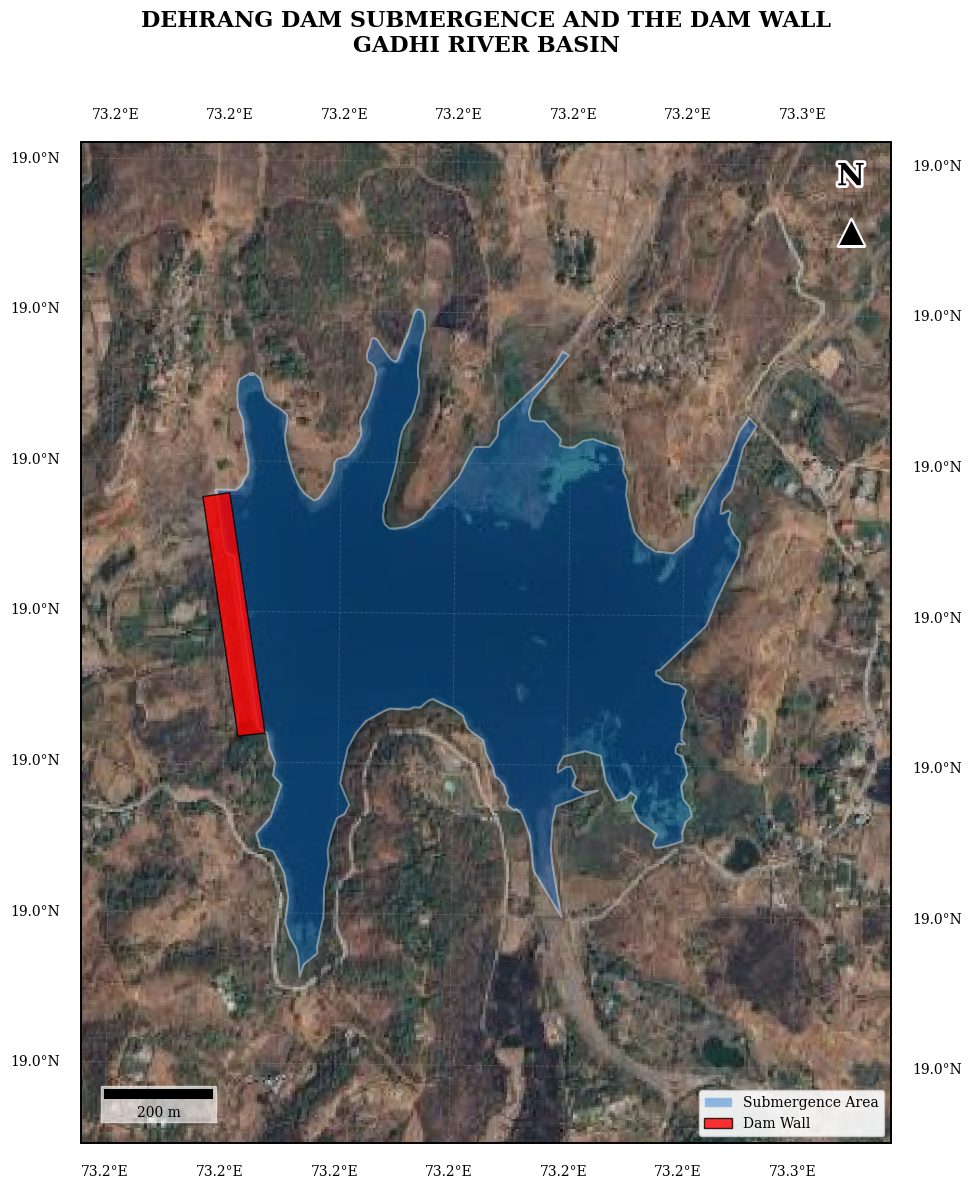

In [115]:
import geopandas as gpd
import cartopy.io.img_tiles as cimgt
print("Rendering Map 6 — Reservoir Submergence & Dam Wall with Basemap …")
sub_path = "Reservoir_Submergence_Dehrang.shp"
wall_path = "Damwall.shp"
gdf_sub = gpd.read_file(sub_path)
gdf_wall = gpd.read_file(wall_path)
if gdf_sub.crs is not None and gdf_sub.crs.to_epsg() != dem_epsg:
    gdf_sub = gdf_sub.to_crs(epsg=dem_epsg)
if gdf_wall.crs is not None and gdf_wall.crs.to_epsg() != dem_epsg:
    gdf_wall = gdf_wall.to_crs(epsg=dem_epsg)
gdf_wall_styled = gdf_wall.copy()
gdf_wall_styled['geometry'] = gdf_wall.buffer(25, cap_style=2, join_style=2)
fig = plt.figure(figsize=FIG_SIZE)
ax  = fig.add_subplot(1, 1, 1, projection=map_crs)
bounds = gdf_sub.total_bounds
pad_x = (bounds[2] - bounds[0]) * 0.25
pad_y = (bounds[3] - bounds[1]) * 0.25
zoomed_extent = [bounds[0] - pad_x, bounds[2] + pad_x, bounds[1] - pad_y, bounds[3] + pad_y]
ax.set_extent(zoomed_extent, crs=map_crs)
tiler = cimgt.GoogleTiles(style='satellite')
ax.add_image(tiler, 15)
gdf_sub.plot(ax=ax, facecolor='#0064C8', edgecolor='#FFFFFF', linewidth=1.5, alpha=0.4, zorder=3, transform=map_crs)
gdf_wall_styled.plot(ax=ax, facecolor='#FF0000', edgecolor='#000000', linewidth=1, alpha=0.8, zorder=4, transform=map_crs)
add_decimal_grid(ax)
add_north_arrow(ax)
add_scalebar(ax, map_crs)
patches = [
    mpatches.Patch(facecolor='#0064C8', edgecolor='#FFFFFF', alpha=0.4, label='Submergence Area'),
    mpatches.Patch(facecolor='#FF0000', edgecolor='#000000', alpha=0.8, label='Dam Wall')
]
ax.legend(handles=patches, loc='lower right', fontsize=10, framealpha=0.9, prop={'family': FONT_SERIF})
finish_map(ax, 'DEHRANG DAM SUBMERGENCE AND THE DAM WALL', WATERSHED_NAME, fig, f'{OUTPUT_DIR}/06_Reservoir_Submergence_Basemap.png')

## 🗺️ Map 7 — Comprehensive Study Area Map
*Integrating Basin, River Systems, and Project Components on Satellite Basemap*

In [116]:
fig = plt.figure(figsize=FIG_SIZE)
ax = fig.add_subplot(1, 1, 1, projection=map_crs)
ax.set_extent(study_extent, crs=map_crs)
ax.add_image(cimgt.GoogleTiles(style='satellite'), 14)
basin.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=3.5, zorder=5, transform=map_crs)
basin.plot(ax=ax, facecolor='none', edgecolor='#00FF00', linewidth=1.5, zorder=6, transform=map_crs)
river_buffer.plot(ax=ax, facecolor='#FFD700', alpha=0.4, zorder=3, transform=map_crs)
river_line.plot(ax=ax, color='#00FFFF', linewidth=2.0, zorder=4, transform=map_crs, path_effects=[pe.withStroke(linewidth=3, foreground='black')])
submergence.plot(ax=ax, facecolor='#104E8B', edgecolor='#FFFFFF', linewidth=1.0, alpha=0.6, zorder=7, transform=map_crs)
dam_wall.buffer(25, cap_style=2, join_style=2).plot(ax=ax, facecolor='#FF00FF', edgecolor='white', linewidth=0.7, zorder=8, transform=map_crs)
add_decimal_grid(ax)
add_north_arrow(ax)
add_scalebar(ax, map_crs)
leg = ax.legend(handles=study_patches, loc='lower right', fontsize=11, framealpha=0.9, prop={'family': FONT_SERIF}, title="PROJECT OVERVIEW")
plt.setp(leg.get_title(), fontweight='bold', family=FONT_SERIF)
finish_map(ax, 'NEW DESIGN: STUDY AREA COMPREHENSIVE MAP', WATERSHED_NAME, fig, f'{OUTPUT_DIR}/07_Study_Area_Map_Redesigned.png')
print("✅ Map rendered with fixed North Arrow!")

Output hidden; open in https://colab.research.google.com to view.

In [117]:
# Update ZIP creation to include the 6th map
zip_path = '/content/DA_Maps_Professional_Suite.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(os.listdir(OUTPUT_DIR)):
        if f.endswith('.png'):
            zf.write(os.path.join(OUTPUT_DIR, f), f)
            print(f"  ✓ Added: {f}")

files.download(zip_path)

  ✓ Added: 01_DEM_Copernicus.png
  ✓ Added: 02_LULC_ESA_WorldCover.png
  ✓ Added: 03_CN_Grid.png
  ✓ Added: 04_HSG_Grid.png
  ✓ Added: 05_Mannings_n.png
  ✓ Added: 06_Reservoir_Submergence.png
  ✓ Added: 06_Reservoir_Submergence_Basemap.png
  ✓ Added: 06_Reservoir_Submergence_Zoomed.png
  ✓ Added: 07_Study_Area_Map_Full.png
  ✓ Added: 07_Study_Area_Map_Redesigned.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
zip_path = '/content/DA_Maps_300dpi.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(os.listdir(OUTPUT_DIR)):
        if f.endswith('.png'):
            zf.write(os.path.join(OUTPUT_DIR, f), f)
            print(f"  ✓ Added: {f}")

print(f"\n📦 ZIP size: {os.path.getsize(zip_path)/1e6:.1f} MB")
files.download(zip_path)
print("✅ Download started — DA_Maps_300dpi.zip")
